In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [18]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [19]:
X = df.iloc[:, [3, 4]].values   # Annual Income, Spending Score

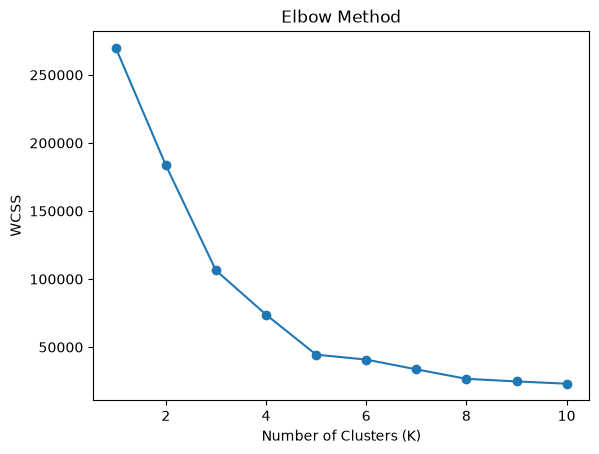

In [20]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

In [21]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

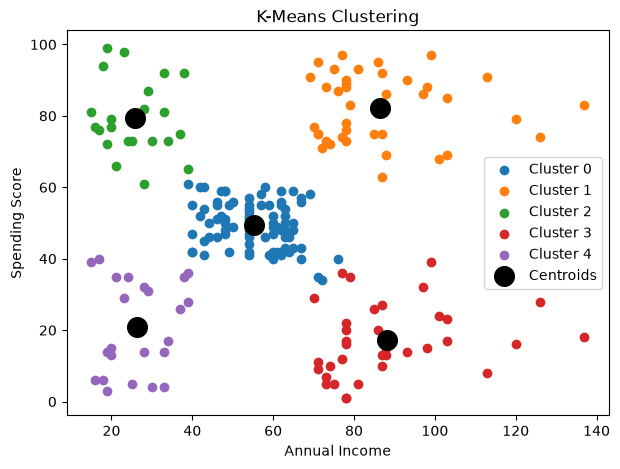

In [22]:
plt.figure(figsize=(7,5))

for i in range(5):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1], label=f'Cluster {i}')

plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, c='black', label='Centroids')

plt.title("K-Means Clustering")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

In [23]:
score_kmeans = silhouette_score(X, y_kmeans)
print("K-Means Silhouette Score:", score_kmeans)

K-Means Silhouette Score: 0.553931997444648


In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [25]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
y_dbscan = dbscan.fit_predict(X_scaled)

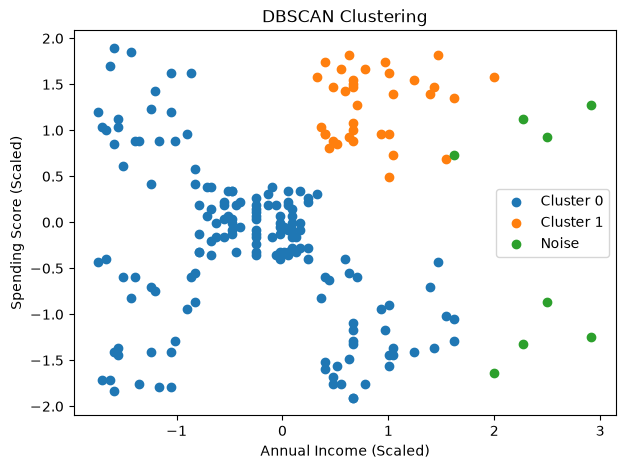

In [26]:
plt.figure(figsize=(7,5))

unique_labels = set(y_dbscan)

for label in unique_labels:
    if label == -1:
        color = 'black'
        name = "Noise"
    else:
        color = None
        name = f"Cluster {label}"

    plt.scatter(X_scaled[y_dbscan == label, 0],
                X_scaled[y_dbscan == label, 1],
                label=name)

plt.title("DBSCAN Clustering")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.legend()
plt.show()

In [27]:
# remove noise (-1) for score
mask = y_dbscan != -1

if len(set(y_dbscan)) > 1:
    score_dbscan = silhouette_score(X_scaled[mask], y_dbscan[mask])
    print("DBSCAN Silhouette Score:", score_dbscan)
else:
    print("DBSCAN found only noise or one cluster")

DBSCAN Silhouette Score: 0.3875583892728279


In [28]:
print("K-Means Score:", score_kmeans)
print("DBSCAN Score:", score_dbscan if 'score_dbscan' in locals() else "N/A")

K-Means Score: 0.553931997444648
DBSCAN Score: 0.3875583892728279
